开始带有轨迹记录的 RBM 模拟...
模拟结束，正在生成图像...


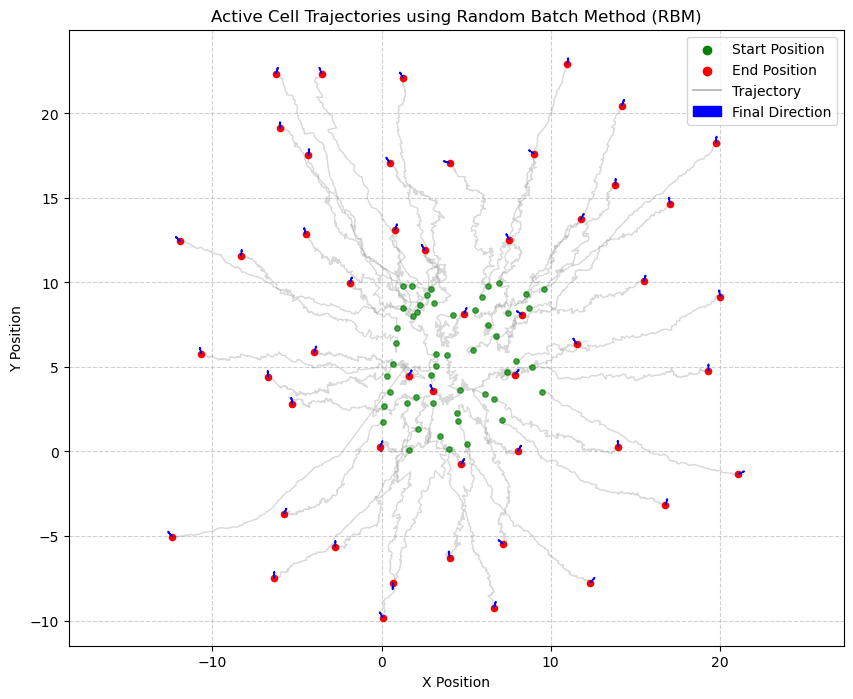

In [1]:
#RBM代码sde
import numpy as np
import matplotlib.pyplot as plt

# --- 物理核函数占位 (与之前相同) ---
def K1_short_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist**2) 

def K2_long_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def calc_deterministic_torque(P_i):
    gravity_dir = np.array([0.0, 1.0]) 
    return gravity_dir - P_i 

# --- 修改后的主模拟函数：增加轨迹记录 ---
def simulate_active_cells_rbm_track(N=50, p=2, tau=0.01, T=2.0, dim=2):
    V_s = 1.0           
    D_r = 0.1           
    sigma_pos = 0.05    
    r_cutoff = 0.5      
    
    # 初始化
    X = np.random.rand(N, dim) * 10.0
    P = np.random.randn(N, dim)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    
    num_steps = int(T / tau)
    
    # 创建一个数组来记录所有时间步的位置：形状为 (步数, 粒子数, 维度)
    X_history = np.zeros((num_steps, N, dim))
    
    for m in range(num_steps):
        X_new = np.copy(X)
        P_new = np.copy(P)
        
        indices = np.random.permutation(N)
        batches = [indices[k:k+p] for k in range(0, N, p)]
        
        for batch in batches:
            current_p = len(batch)
            
            for i in batch:
                # 短程力
                dx_all = X[i] - X
                distances = np.linalg.norm(dx_all, axis=1)
                mask_short = (distances < r_cutoff) & (np.arange(N) != i)
                neighbors_short = np.where(mask_short)[0]
                
                F_short = np.zeros(dim)
                for j in neighbors_short:
                    F_short += K1_short_range(X[i] - X[j])
                
                # 长程力 (RBM 核心)
                F_long_random = np.zeros(dim)
                if current_p >= 2:
                    for j in batch:
                        if j != i:
                            F_long_random += K2_long_range(X[i] - X[j])
                    F_long = F_long_random * (N - 1) / (current_p - 1)
                else:
                    F_long = np.zeros(dim)
                
                U_interact = F_short + F_long
                
                # SDE 更新
                dW_pos = np.random.randn(dim) * np.sqrt(tau)
                dW_rot = np.random.randn(dim) * np.sqrt(tau)
                
                X_new[i] = X[i] + (V_s * P[i] + U_interact) * tau + sigma_pos * dW_pos
                deterministic_torque = calc_deterministic_torque(P[i])
                P_new[i] = P[i] + deterministic_torque * tau + np.sqrt(2 * D_r) * dW_rot
                P_new[i] = P_new[i] / np.linalg.norm(P_new[i])
                
        X = X_new
        P = P_new
        
        # 记录当前步的位置
        X_history[m] = X

    return X_history, P

# --- 可视化函数 ---
def plot_trajectories(X_history, final_P):
    """
    绘制细胞的运动轨迹
    """
    plt.figure(figsize=(10, 8))
    
    N = X_history.shape[1]
    num_steps = X_history.shape[0]
    
    # 1. 绘制轨迹线
    for i in range(N):
        # 取出第 i 个细胞在所有时间步的 x 和 y 坐标
        x_traj = X_history[:, i, 0]
        y_traj = X_history[:, i, 1]
        
        # 绘制半透明的轨迹线
        plt.plot(x_traj, y_traj, color='gray', alpha=0.3, linewidth=1)
        
        # 2. 标记起点 (绿色圆点)
        plt.scatter(x_traj[0], y_traj[0], color='green', s=15, zorder=3, alpha=0.7)
        
        # 3. 标记终点 (红色圆点) 并在终点画出游动方向箭头
        plt.scatter(x_traj[-1], y_traj[-1], color='red', s=20, zorder=4)
        # 画方向箭头：dx, dy 取自 final_P，适当缩放长度方便观察
        arrow_length = 0.3
        plt.arrow(x_traj[-1], y_traj[-1], 
                  final_P[i, 0] * arrow_length, final_P[i, 1] * arrow_length, 
                  head_width=0.08, head_length=0.1, fc='blue', ec='blue', zorder=5)

    # 图例占位
    plt.scatter([], [], color='green', label='Start Position')
    plt.scatter([], [], color='red', label='End Position')
    plt.plot([], [], color='gray', alpha=0.5, label='Trajectory')
    plt.arrow(0, 0, 0, 0, head_width=0.1, fc='blue', ec='blue', label='Final Direction')

    plt.title("Active Cell Trajectories using Random Batch Method (RBM)")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal') # 保持XY轴比例一致
    plt.show()

# --- 运行测试与绘图 ---
if __name__ == "__main__":
    print("开始带有轨迹记录的 RBM 模拟...")
    # 为了图像不至于太杂乱，这里将细胞数 N 减少到 50
    history, final_directions = simulate_active_cells_rbm_track(N=50, p=2, tau=0.01, T=3.0, dim=2)
    print("模拟结束，正在生成图像...")
    plot_trajectories(history, final_directions)

开始带有轨迹记录的全相互作用 (No RBM) 模拟...
模拟结束，正在生成图像...


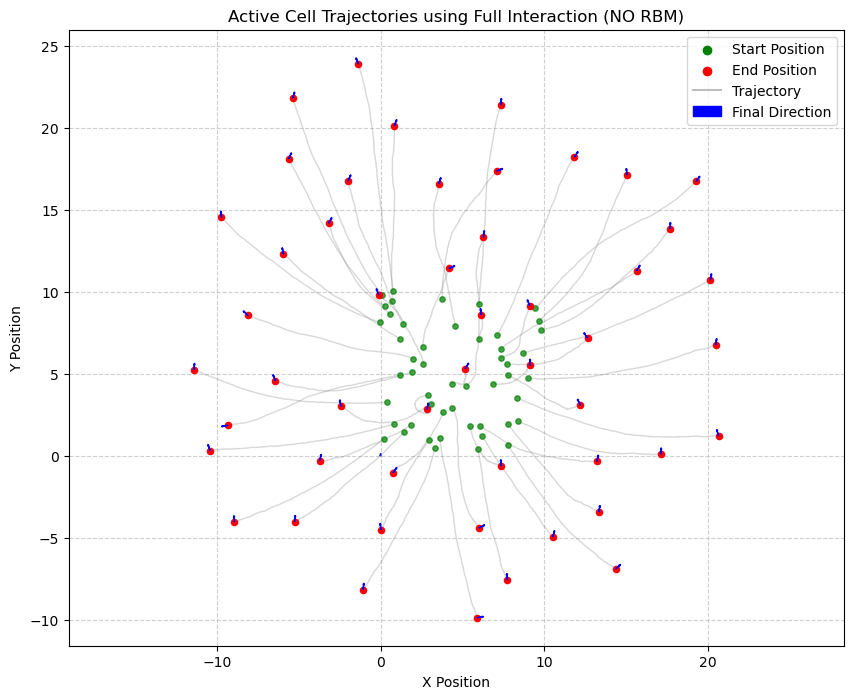

In [2]:
#传统算法sde
import numpy as np
import matplotlib.pyplot as plt

# --- 物理核函数占位 (与之前完全相同) ---
def K1_short_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist**2) 

def K2_long_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def calc_deterministic_torque(P_i):
    gravity_dir = np.array([0.0, 1.0]) 
    return gravity_dir - P_i 

# --- 修改后的主模拟函数：传统全相互作用 (No RBM) ---
def simulate_active_cells_full_track(N=50, tau=0.01, T=3.0, dim=2):
    V_s = 1.0           
    D_r = 0.1           
    sigma_pos = 0.05    
    r_cutoff = 0.5      
    
    # 相同的初始化
    np.random.seed(42) # 固定随机种子，方便你对比两条轨迹的差异
    X = np.random.rand(N, dim) * 10.0
    P = np.random.randn(N, dim)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    
    num_steps = int(T / tau)
    X_history = np.zeros((num_steps, N, dim))
    
    for m in range(num_steps):
        X_new = np.copy(X)
        P_new = np.copy(P)
        
        # ⚠️ 这里没有了 random.permutation 和 batches 划分
        # 直接遍历所有 N 个细胞
        for i in range(N):
            
            # --- 计算相互作用力 (O(N^2) 复杂度) ---
            dx_all = X[i] - X
            distances = np.linalg.norm(dx_all, axis=1)
            
            # 1. 短程力 (仅限距离小于 r_cutoff 且不是自己)
            mask_short = (distances < r_cutoff) & (np.arange(N) != i)
            neighbors_short = np.where(mask_short)[0]
            
            F_short = np.zeros(dim)
            for j in neighbors_short:
                F_short += K1_short_range(X[i] - X[j])
            
            # 2. 长程力 (与剩余的全体 N-1 个细胞计算，无需 RBM 放大权重)
            mask_long = (np.arange(N) != i)
            neighbors_long = np.where(mask_long)[0]
            
            F_long = np.zeros(dim)
            for j in neighbors_long:
                F_long += K2_long_range(X[i] - X[j])
                
            # 总作用力
            U_interact = F_short + F_long
            
            # --- SDE 更新 (与之前完全相同) ---
            dW_pos = np.random.randn(dim) * np.sqrt(tau)
            dW_rot = np.random.randn(dim) * np.sqrt(tau)
            
            X_new[i] = X[i] + (V_s * P[i] + U_interact) * tau + sigma_pos * dW_pos
            deterministic_torque = calc_deterministic_torque(P[i])
            P_new[i] = P[i] + deterministic_torque * tau + np.sqrt(2 * D_r) * dW_rot
            P_new[i] = P_new[i] / np.linalg.norm(P_new[i])
                
        X = X_new
        P = P_new
        
        # 记录当前步的位置
        X_history[m] = X

    return X_history, P

# --- 可视化函数 (与之前完全相同) ---
def plot_trajectories(X_history, final_P):
    plt.figure(figsize=(10, 8))
    N = X_history.shape[1]
    
    for i in range(N):
        x_traj = X_history[:, i, 0]
        y_traj = X_history[:, i, 1]
        
        plt.plot(x_traj, y_traj, color='gray', alpha=0.3, linewidth=1)
        plt.scatter(x_traj[0], y_traj[0], color='green', s=15, zorder=3, alpha=0.7)
        plt.scatter(x_traj[-1], y_traj[-1], color='red', s=20, zorder=4)
        
        arrow_length = 0.3
        plt.arrow(x_traj[-1], y_traj[-1], 
                  final_P[i, 0] * arrow_length, final_P[i, 1] * arrow_length, 
                  head_width=0.08, head_length=0.1, fc='blue', ec='blue', zorder=5)

    plt.scatter([], [], color='green', label='Start Position')
    plt.scatter([], [], color='red', label='End Position')
    plt.plot([], [], color='gray', alpha=0.5, label='Trajectory')
    plt.arrow(0, 0, 0, 0, head_width=0.1, fc='blue', ec='blue', label='Final Direction')

    plt.title("Active Cell Trajectories using Full Interaction (NO RBM)")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal') 
    plt.show()

# --- 运行测试与绘图 ---
if __name__ == "__main__":
    print("开始带有轨迹记录的全相互作用 (No RBM) 模拟...")
    # 保持参数不变：N=50
    history, final_directions = simulate_active_cells_full_track(N=50, tau=0.01, T=3.0, dim=2)
    print("模拟结束，正在生成图像...")
    plot_trajectories(history, final_directions)

开始性能基准测试 (模拟 50 步)...
正在测试 N = 100 ...
  RBM 耗时: 0.1156 秒 | Full 耗时: 5.1243 秒
正在测试 N = 200 ...
  RBM 耗时: 0.2062 秒 | Full 耗时: 18.8002 秒
正在测试 N = 400 ...
  RBM 耗时: 0.4345 秒 | Full 耗时: 66.9181 秒


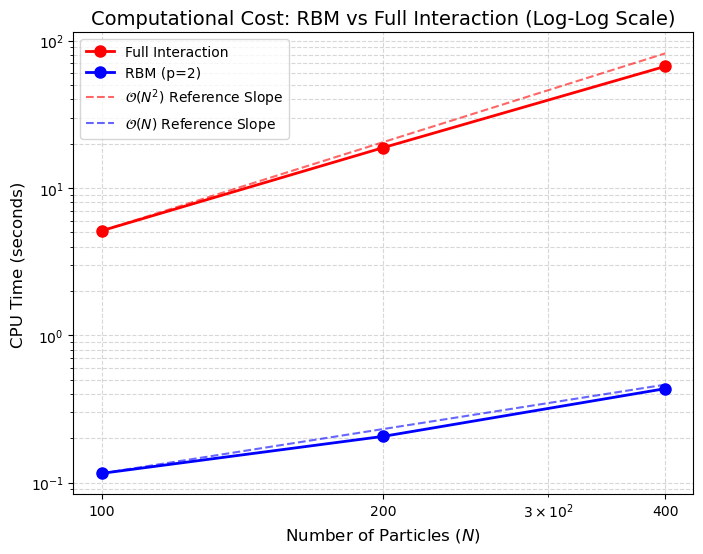

测试完成！


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

def K2_long_range_simple(dx):
    """简化的长程力计算，用于性能测试"""
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def run_benchmark_rbm(N, steps=50, p=2, dim=2):
    """RBM 算法的时间测试 (预期复杂度 O(N))"""
    X = np.random.rand(N, dim) * 10.0
    
    start_time = time.time()
    for _ in range(steps):
        X_new = np.copy(X)
        indices = np.random.permutation(N)
        
        for k in range(0, N, p):
            batch = indices[k:k+p]
            current_p = len(batch)
            if current_p < 2: continue
                
            for i in batch:
                F_long = np.zeros(dim)
                for j in batch:
                    if j != i:
                        F_long += K2_long_range_simple(X[i] - X[j])
                # 无偏估计放大
                F_long = F_long * (N - 1) / (current_p - 1)
                
                # 仅做最基础的位置更新，忽略噪声和力矩以专注测算力计算的耗时
                X_new[i] += F_long * 0.01 
        X = X_new
    return time.time() - start_time

def run_benchmark_full(N, steps=50, dim=2):
    """全相互作用的时间测试 (预期复杂度 O(N^2))"""
    X = np.random.rand(N, dim) * 10.0
    
    start_time = time.time()
    for _ in range(steps):
        X_new = np.copy(X)
        
        for i in range(N):
            F_long = np.zeros(dim)
            # 遍历所有其他粒子 (这就是 O(N^2) 耗时的万恶之源)
            for j in range(N):
                if j != i:
                    F_long += K2_long_range_simple(X[i] - X[j])
                    
            X_new[i] += F_long * 0.01
        X = X_new
    return time.time() - start_time

if __name__ == "__main__":
    # 测试的粒子数列表 (成倍增加)
    N_list = [100, 200, 400]
    
    time_rbm = []
    time_full = []
    
    print("开始性能基准测试 (模拟 50 步)...")
    for N in N_list:
        print(f"正在测试 N = {N} ...")
        
        # 跑 RBM
        t_rbm = run_benchmark_rbm(N, steps=50, p=2)
        time_rbm.append(t_rbm)
        
        # 跑 Full Method
        t_full = run_benchmark_full(N, steps=50)
        time_full.append(t_full)
        
        print(f"  RBM 耗时: {t_rbm:.4f} 秒 | Full 耗时: {t_full:.4f} 秒")

    # --- 绘制双对数对比图 (Log-Log Plot) ---
    plt.figure(figsize=(8, 6))
    
    # 将结果转换为 numpy 数组以便计算
    N_arr = np.array(N_list)
    time_rbm_arr = np.array(time_rbm)
    time_full_arr = np.array(time_full)
    
    # 画出实际测量的时间点
    plt.plot(N_arr, time_full_arr, 'ro-', linewidth=2, markersize=8, label='Full Interaction')
    plt.plot(N_arr, time_rbm_arr, 'bo-', linewidth=2, markersize=8, label='RBM (p=2)')
    
    # 画出理论的斜率参考线 (为了美观，我们以上下平移的方式对齐第一个点)
    # O(N^2) 参考线：时间与 N^2 成正比
    ref_N2 = time_full_arr[0] * (N_arr / N_arr[0])**2 
    plt.plot(N_arr, ref_N2, 'r--', alpha=0.6, label='$\mathcal{O}(N^2)$ Reference Slope')
    
    # O(N) 参考线：时间与 N 成正比
    ref_N1 = time_rbm_arr[0] * (N_arr / N_arr[0])**1
    plt.plot(N_arr, ref_N1, 'b--', alpha=0.6, label='$\mathcal{O}(N)$ Reference Slope')

    # 设置双对数坐标轴
    plt.xscale('log')
    plt.yscale('log')
    
    # 设置坐标轴刻度和标签
    plt.xticks(N_list, [str(n) for n in N_list])
    plt.xlabel('Number of Particles ($N$)', fontsize=12)
    plt.ylabel('CPU Time (seconds)', fontsize=12)
    plt.title('Computational Cost: RBM vs Full Interaction (Log-Log Scale)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.show()
    print("测试完成！")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

def K2_long_range_simple(dx):
    """简化的长程力计算，用于性能测试"""
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def run_benchmark_rbm(N, steps=50, p=2, dim=2):
    """RBM 算法的时间测试 (预期复杂度 O(N))"""
    X = np.random.rand(N, dim) * 10.0
    
    start_time = time.time()
    for _ in range(steps):
        X_new = np.copy(X)
        indices = np.random.permutation(N)
        
        for k in range(0, N, p):
            batch = indices[k:k+p]
            current_p = len(batch)
            if current_p < 2: continue
                
            for i in batch:
                F_long = np.zeros(dim)
                for j in batch:
                    if j != i:
                        F_long += K2_long_range_simple(X[i] - X[j])
                # 无偏估计放大
                F_long = F_long * (N - 1) / (current_p - 1)
                
                # 仅做最基础的位置更新，忽略噪声和力矩以专注测算力计算的耗时
                X_new[i] += F_long * 0.01 
        X = X_new
    return time.time() - start_time

def run_benchmark_full(N, steps=50, dim=2):
    """全相互作用的时间测试 (预期复杂度 O(N^2))"""
    X = np.random.rand(N, dim) * 10.0
    
    start_time = time.time()
    for _ in range(steps):
        X_new = np.copy(X)
        
        for i in range(N):
            F_long = np.zeros(dim)
            # 遍历所有其他粒子 (这就是 O(N^2) 耗时的万恶之源)
            for j in range(N):
                if j != i:
                    F_long += K2_long_range_simple(X[i] - X[j])
                    
            X_new[i] += F_long * 0.01
        X = X_new
    return time.time() - start_time

if __name__ == "__main__":
    # 测试的粒子数列表 (成倍增加)
    N_list = [1000,2000,3000,4000,6000]
    
    time_rbm = []
    time_full = []
    
    print("开始性能基准测试 (模拟 50 步)...")
    for N in N_list:
        print(f"正在测试 N = {N} ...")
        
        # 跑 RBM
        t_rbm = run_benchmark_rbm(N, steps=50, p=2)
        time_rbm.append(t_rbm)
        
        # 跑 Full Method
       # t_full = run_benchmark_full(N, steps=50)
        #time_full.append(t_full)
        
        print(f"  RBM 耗时: {t_rbm:.4f} 秒 ")


开始性能基准测试 (模拟 50 步)...
正在测试 N = 1000 ...
  RBM 耗时: 1.0290 秒 
正在测试 N = 2000 ...
  RBM 耗时: 1.5138 秒 
正在测试 N = 3000 ...
  RBM 耗时: 2.9697 秒 
正在测试 N = 4000 ...
  RBM 耗时: 3.5548 秒 
正在测试 N = 6000 ...
  RBM 耗时: 5.6600 秒 


开始带有轨迹记录的 RBM 模拟...
模拟结束，正在生成图像...


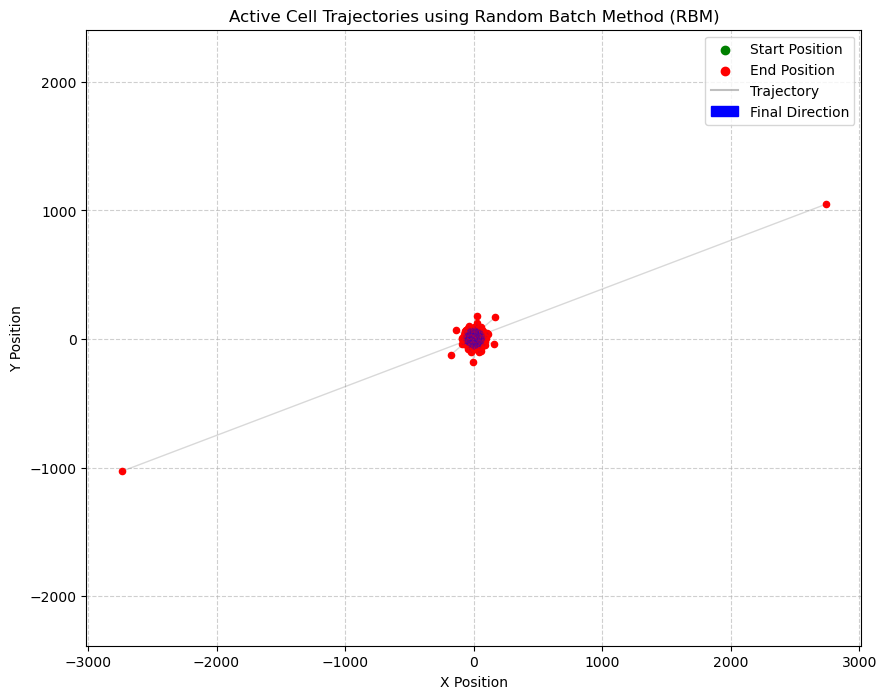

In [5]:
#RBM代码sde
import numpy as np
import matplotlib.pyplot as plt

# --- 物理核函数占位 (与之前相同) ---
def K1_short_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist**2) 

def K2_long_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def calc_deterministic_torque(P_i):
    gravity_dir = np.array([0.0, 1.0]) 
    return gravity_dir - P_i 

# --- 修改后的主模拟函数：增加轨迹记录 ---
def simulate_active_cells_rbm_track(N, p=2, tau=0.01, T=2.0, dim=2):
    V_s = 1.0           
    D_r = 0.1           
    sigma_pos = 0.05    
    r_cutoff = 0.5      
    
    # 初始化
    X = np.random.rand(N, dim) * 10.0
    P = np.random.randn(N, dim)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    
    num_steps = int(T / tau)
    
    # 创建一个数组来记录所有时间步的位置：形状为 (步数, 粒子数, 维度)
    X_history = np.zeros((num_steps, N, dim))
    
    for m in range(num_steps):
        X_new = np.copy(X)
        P_new = np.copy(P)
        
        indices = np.random.permutation(N)
        batches = [indices[k:k+p] for k in range(0, N, p)]
        
        for batch in batches:
            current_p = len(batch)
            
            for i in batch:
                # 短程力
                dx_all = X[i] - X
                distances = np.linalg.norm(dx_all, axis=1)
                mask_short = (distances < r_cutoff) & (np.arange(N) != i)
                neighbors_short = np.where(mask_short)[0]
                
                F_short = np.zeros(dim)
                for j in neighbors_short:
                    F_short += K1_short_range(X[i] - X[j])
                
                # 长程力 (RBM 核心)
                F_long_random = np.zeros(dim)
                if current_p >= 2:
                    for j in batch:
                        if j != i:
                            F_long_random += K2_long_range(X[i] - X[j])
                    F_long = F_long_random * (N - 1) / (current_p - 1)
                else:
                    F_long = np.zeros(dim)
                
                U_interact = F_short + F_long
                
                # SDE 更新
                dW_pos = np.random.randn(dim) * np.sqrt(tau)
                dW_rot = np.random.randn(dim) * np.sqrt(tau)
                
                X_new[i] = X[i] + (V_s * P[i] + U_interact) * tau + sigma_pos * dW_pos
                deterministic_torque = calc_deterministic_torque(P[i])
                P_new[i] = P[i] + deterministic_torque * tau + np.sqrt(2 * D_r) * dW_rot
                P_new[i] = P_new[i] / np.linalg.norm(P_new[i])
                
        X = X_new
        P = P_new
        
        # 记录当前步的位置
        X_history[m] = X

    return X_history, P

# --- 可视化函数 ---
def plot_trajectories(X_history, final_P):
    """
    绘制细胞的运动轨迹
    """
    plt.figure(figsize=(10, 8))
    
    N = X_history.shape[1]
    num_steps = X_history.shape[0]
    
    # 1. 绘制轨迹线
    for i in range(N):
        # 取出第 i 个细胞在所有时间步的 x 和 y 坐标
        x_traj = X_history[:, i, 0]
        y_traj = X_history[:, i, 1]
        
        # 绘制半透明的轨迹线
        plt.plot(x_traj, y_traj, color='gray', alpha=0.3, linewidth=1)
        
        # 2. 标记起点 (绿色圆点)
        plt.scatter(x_traj[0], y_traj[0], color='green', s=15, zorder=3, alpha=0.7)
        
        # 3. 标记终点 (红色圆点) 并在终点画出游动方向箭头
        plt.scatter(x_traj[-1], y_traj[-1], color='red', s=20, zorder=4)
        # 画方向箭头：dx, dy 取自 final_P，适当缩放长度方便观察
        arrow_length = 0.3
        plt.arrow(x_traj[-1], y_traj[-1], 
                  final_P[i, 0] * arrow_length, final_P[i, 1] * arrow_length, 
                  head_width=0.08, head_length=0.1, fc='blue', ec='blue', zorder=5)

    # 图例占位
    plt.scatter([], [], color='green', label='Start Position')
    plt.scatter([], [], color='red', label='End Position')
    plt.plot([], [], color='gray', alpha=0.5, label='Trajectory')
    plt.arrow(0, 0, 0, 0, head_width=0.1, fc='blue', ec='blue', label='Final Direction')

    plt.title("Active Cell Trajectories using Random Batch Method (RBM)")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal') # 保持XY轴比例一致
    plt.show()

# --- 运行测试与绘图 ---
if __name__ == "__main__":
    print("开始带有轨迹记录的 RBM 模拟...")
    # 为了图像不至于太杂乱，这里将细胞数 N 减少到 50
    history, final_directions = simulate_active_cells_rbm_track(N=1000, p=2, tau=0.01, T=3.0, dim=2)
    print("模拟结束，正在生成图像...")
    plot_trajectories(history, final_directions)